In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymannkendall as mk

# Esse pymannkendall é muito usado em climatologia, hidrologia e series temporais ambientais. 
#Porque ele nao assume que os dados seguem uma distribuição normal, o que é comum em dados ambientais.



In [123]:
sns.set_theme(style="whitegrid")

In [124]:
file_path = "../data/raw/Dados climáticos de 1984 a 2014 - Formatado.xlsx"

In [125]:
dados = pd.read_excel(file_path, sheet_name="dados")

In [126]:
dados.head()

,Data,mm/dia - Precipitação,mm/dia - Evapotranspiração,C° - Temperatura Média,W/m² - Radiação
0,1984-01-01,0.989776,0.518743,25.419519,211.801254
1,1984-01-02,0.166336,0.587044,26.399133,204.752853
2,1984-01-03,0.256648,0.419522,26.202539,217.430527
3,1984-01-04,0.000000,0.478503,26.720331,222.075912
4,1984-01-05,0.000000,0.374592,27.286249,220.100525


In [127]:
# Converter a coluna "Data" para datetime e criar a coluna "Ano" (necessária para o groupby anual)
dados["Data"] = pd.to_datetime(dados["Data"], errors="coerce")
dados["Ano"] = dados["Data"].dt.year

In [128]:
# Padronizar nomes das colunas (remove espaços extras)
dados.columns = dados.columns.astype(str).str.strip()

# (Opcional) checagem rápida das colunas presentes no arquivo bruto
colunas_esperadas = [
    "Data",
    "mm/dia - Precipitação",
    "mm/dia - Evapotranspiração",
    "C° - Temperatura Média",
    "W/m² - Radiação",
]
faltando = [c for c in colunas_esperadas if c not in dados.columns]
if faltando:
    print("Atenção: colunas esperadas não encontradas:", faltando)

In [129]:
dados.head()

,Data,mm/dia - Precipitação,mm/dia - Evapotranspiração,C° - Temperatura Média,W/m² - Radiação,Ano
0,1984-01-01,0.989776,0.518743,25.419519,211.801254,1984
1,1984-01-02,0.166336,0.587044,26.399133,204.752853,1984
2,1984-01-03,0.256648,0.419522,26.202539,217.430527,1984
3,1984-01-04,0.000000,0.478503,26.720331,222.075912,1984
4,1984-01-05,0.000000,0.374592,27.286249,220.100525,1984


In [130]:
# Criando a coluna "Ano" a partir da coluna "Data" para facilitar a análise anual
dados_anuais = dados.groupby("Ano").mean(numeric_only=True)

In [131]:
dados_anuais.head()

,mm/dia - Precipitação,mm/dia - Evapotranspiração,C° - Temperatura Média,W/m² - Radiação
Ano,,,,
1984,3.475377,2.917792,25.014692,187.170089
1985,4.930112,3.569107,24.779909,176.638726
1986,4.396067,3.748965,24.720468,178.409360
1987,2.398333,2.635569,25.155278,190.456368
1988,3.043852,2.792325,25.134505,185.707359


In [132]:
# (Re)usar o dataframe anual já calculado acima
dados_anuais.head()

,mm/dia - Precipitação,mm/dia - Evapotranspiração,C° - Temperatura Média,W/m² - Radiação
Ano,,,,
1984,3.475377,2.917792,25.014692,187.170089
1985,4.930112,3.569107,24.779909,176.638726
1986,4.396067,3.748965,24.720468,178.409360
1987,2.398333,2.635569,25.155278,190.456368
1988,3.043852,2.792325,25.134505,185.707359


In [133]:
dados_anuais.head()

,mm/dia - Precipitação,mm/dia - Evapotranspiração,C° - Temperatura Média,W/m² - Radiação
Ano,,,,
1984,3.475377,2.917792,25.014692,187.170089
1985,4.930112,3.569107,24.779909,176.638726
1986,4.396067,3.748965,24.720468,178.409360
1987,2.398333,2.635569,25.155278,190.456368
1988,3.043852,2.792325,25.134505,185.707359


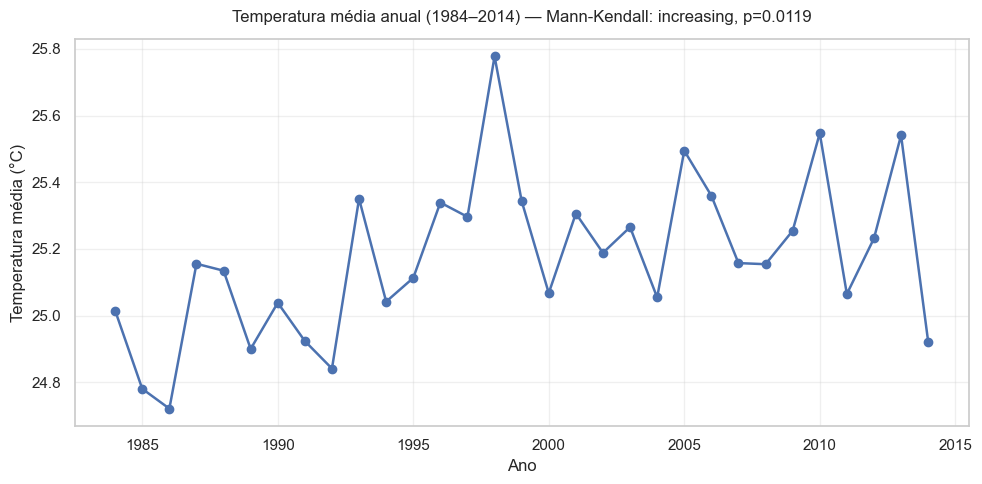

In [134]:
# Gráfico (padrão artigo) da tendência anual da temperatura com resumo do Mann-Kendall no título
temp_col = "C° - Temperatura Média"
mk_temp = mk.original_test(dados_anuais[temp_col])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dados_anuais.index, dados_anuais[temp_col], marker="o", linewidth=1.8)
ax.set_title(
    f"Temperatura média anual (1984–2014) — Mann-Kendall: {mk_temp.trend}, p={mk_temp.p:.4f}",
    pad=12,
 )
ax.set_xlabel("Ano")
ax.set_ylabel("Temperatura média (°C)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

O gráfico sugere uma leve tendência de aumento da temperatura ao longo do período.

Mas apenas olhar o gráfico não é suficiente.

Por isso usamos o teste estatístico Mann-Kendall.

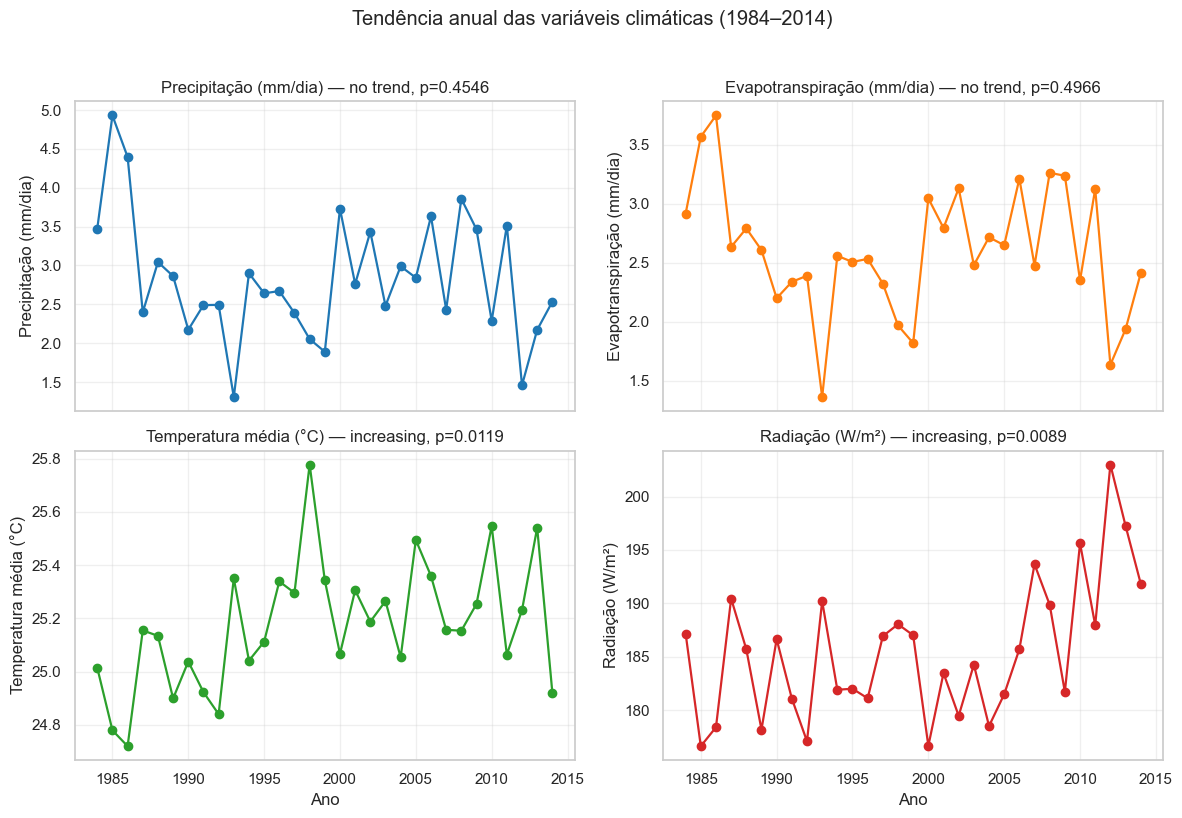

In [135]:
# Painel 2x2 (padrão artigo): eixos com unidades, cores por variável e resumo MK no título
series_info = {
    "mm/dia - Precipitação": {"ylabel": "Precipitação (mm/dia)", "color": "tab:blue"},
    "mm/dia - Evapotranspiração": {"ylabel": "Evapotranspiração (mm/dia)", "color": "tab:orange"},
    "C° - Temperatura Média": {"ylabel": "Temperatura média (°C)", "color": "tab:green"},
    "W/m² - Radiação": {"ylabel": "Radiação (W/m²)", "color": "tab:red"},
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for ax, (col, cfg) in zip(axes, series_info.items()):
    mk_res = mk.original_test(dados_anuais[col])
    ax.plot(
        dados_anuais.index,
        dados_anuais[col],
        marker="o",
        linewidth=1.6,
        color=cfg["color"],
    )
    ax.set_title(f"{cfg['ylabel']} — {mk_res.trend}, p={mk_res.p:.4f}")
    ax.set_ylabel(cfg["ylabel"])
    ax.grid(True, alpha=0.3)

for ax in axes[-2:]:
    ax.set_xlabel("Ano")

fig.suptitle("Tendência anual das variáveis climáticas (1984–2014)", y=1.02)
plt.tight_layout()
plt.show()

Isso cria quatro gráficos:

- precipitação anual
- evapotranspiração anual
- temperatura média anual
- radiação anual

## O que os gráficos mostram

### Precipitação

Apresenta grande variação entre os anos.

Não é possível observar uma tendência clara de aumento ou diminuição ao longo do período analisado.

Esse comportamento é típico da precipitação em regiões semiáridas, onde a chuva ocorre de forma irregular.

---

### Evapotranspiração

A evapotranspiração apresenta oscilações ao longo dos anos.

Entretanto, assim como na precipitação, não é possível identificar uma tendência clara de crescimento ou redução ao longo da série temporal.

---

### Temperatura

A temperatura média apresenta um leve aumento ao longo do tempo.

Esse comportamento pode indicar um possível processo de aquecimento regional ao longo do período analisado.

---

### Radiação

A radiação solar também apresenta uma leve tendência de aumento ao longo dos anos analisados.


In [136]:
resultado_temp = mk.original_test(dados_anuais["C° - Temperatura Média"])

resultado_temp

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.011887389113116376), z=np.float64(2.515469711031328), Tau=np.float64(0.3204301075268817), s=np.float64(149.0), var_s=3461.6666666666665, slope=np.float64(0.012873962734593545), intercept=np.float64(24.96216810144687))

## Teste de Tendência de Mann-Kendall — Temperatura Média

Para verificar a existência de tendência temporal na série histórica da temperatura média, foi aplicado o teste não paramétrico de Mann-Kendall utilizando a biblioteca `pymannkendall`.

O teste foi executado com o seguinte código:

```python
resultado_temp = mk.original_test(dados_anuais["C° - Temperatura Média"])
resultado_temp
```

### Resultado do Teste

```
Mann_Kendall_Test(
trend='increasing',
h=True,
p=0.011887389113116376,
z=2.515469711031328,
Tau=0.3204301075268817,
s=149.0,
var_s=3461.6666666666665,
slope=0.012873962734593545,
intercept=24.96216810144687
)
```

---

## Interpretação Estatística

O teste de Mann-Kendall avalia as seguintes hipóteses:

- **H₀ (Hipótese nula):** não existe tendência temporal na série.
- **H₁ (Hipótese alternativa):** existe tendência temporal na série.

O resultado apresentou:

- **p-value = 0.0119**

Considerando um nível de significância de 5% (α = 0.05):

```
p-value < 0.05
```

Portanto, rejeita-se a hipótese nula.

Isso indica que **existe uma tendência estatisticamente significativa na temperatura média ao longo do período analisado (1984–2014)**.

---

## Direção da Tendência

O parâmetro:

```
trend = "increasing"
```

indica que a tendência identificada é **crescente**.

Ou seja, a temperatura média apresenta **aumento ao longo do tempo**.

---

## Intensidade da Tendência

O coeficiente de inclinação estimado pelo teste é:

```
slope = 0.0129 °C por ano
```

Isso indica que a temperatura média aumentou aproximadamente:

```
0.0129 °C por ano
```

Ao longo do período analisado.

Em termos acumulados para a série completa (1984–2014):

```
0.0129 × 30 ≈ 0.39 °C
```

Portanto, observa-se um aumento aproximado de **0.39 °C na temperatura média ao longo de 30 anos**.

---

## Interpretação Climática

Os resultados sugerem que a região apresenta **sinais de aquecimento ao longo da série histórica analisada**.

Esse comportamento pode estar associado a fatores como:

- mudanças climáticas regionais
- aumento da radiação solar
- alterações na cobertura de nuvens
- variabilidade climática de longo prazo

Entretanto, análises adicionais seriam necessárias para identificar as causas específicas desse aumento.

---

## Conclusão

O teste de Mann-Kendall indicou **tendência crescente estatisticamente significativa na temperatura média entre 1984 e 2014**.

Esse resultado sugere um processo de **aquecimento gradual na região analisada ao longo do período estudado**.


In [137]:
dados_anuais.columns.tolist()

['mm/dia - Precipitação',
 'mm/dia - Evapotranspiração',
 'C° - Temperatura Média',
 'W/m² - Radiação']

In [138]:
dados_anuais.columns = dados_anuais.columns.str.strip()

In [139]:
dados_anuais.columns.tolist()

['mm/dia - Precipitação',
 'mm/dia - Evapotranspiração',
 'C° - Temperatura Média',
 'W/m² - Radiação']

In [140]:
# Aplicar o teste de Mann-Kendall (original) para cada variável anual
import pymannkendall as mk

# Garantir colunas sem espaços extras também no dataframe anual
dados_anuais.columns = dados_anuais.columns.astype(str).str.strip()

variaveis = [
    "mm/dia - Precipitação",
    "mm/dia - Evapotranspiração",
    "C° - Temperatura Média",
    "W/m² - Radiação",
]

for var in variaveis:
    if var not in dados_anuais.columns:
        raise KeyError(f"Coluna '{var}' não encontrada em dados_anuais. Colunas disponíveis: {list(dados_anuais.columns)}")
    resultado = mk.original_test(dados_anuais[var])
    print(f"\nVariável: {var}")
    print(f"Tendência: {resultado.trend}")
    print(f"p-value: {resultado.p}")
    print(f"S: {resultado.s}")
    print(f"Tau: {resultado.Tau}")
    print(f"Sen's slope: {resultado.slope}")


Variável: mm/dia - Precipitação
Tendência: no trend
p-value: 0.45455525621868187
S: -45.0
Tau: -0.0967741935483871
Sen's slope: -0.01349268352150243

Variável: mm/dia - Evapotranspiração
Tendência: no trend
p-value: 0.49659521437046883
S: -41.0
Tau: -0.08817204301075268
Sen's slope: -0.0083961517180867

Variável: C° - Temperatura Média
Tendência: increasing
p-value: 0.011887389113116376
S: 149.0
Tau: 0.3204301075268817
Sen's slope: 0.012873962734593545

Variável: W/m² - Radiação
Tendência: increasing
p-value: 0.008858992984779324
S: 155.0
Tau: 0.3333333333333333
Sen's slope: 0.3446521595487498


# Etapa 2 — Teste Estatístico de Tendência (Mann-Kendall)

## Objetivo

Após a análise exploratória dos dados, foi aplicado o **teste não paramétrico de Mann-Kendall** para avaliar a existência de tendências significativas nas séries temporais das variáveis climáticas.

O teste de Mann-Kendall é amplamente utilizado em estudos ambientais e climáticos para detectar tendências monotônicas em séries temporais, sem exigir que os dados sigam uma distribuição normal.

---

## Hipóteses do Teste

O teste considera duas hipóteses:

**Hipótese nula (H₀):**  
Não existe tendência temporal na série de dados.

**Hipótese alternativa (H₁):**  
Existe tendência crescente ou decrescente na série temporal.

O critério de decisão utilizado foi o nível de significância:

α = 0.05

Se:

p-value < 0.05 → tendência estatisticamente significativa

Se:

p-value ≥ 0.05 → não há evidência estatística de tendência

---

## Resultados do Teste

O teste foi aplicado às quatro variáveis climáticas analisadas.

### Precipitação

Tendência: **no trend**  
p-value: **0.4546**

Como o p-value é maior que 0.05, não há evidência estatística de tendência significativa na precipitação ao longo do período analisado.

Isso indica que as variações observadas na precipitação estão associadas à variabilidade natural do clima.

---

### Evapotranspiração

Tendência: **no trend**  
p-value: **0.4966**

Assim como na precipitação, a evapotranspiração não apresentou tendência estatisticamente significativa ao longo da série temporal.

---

### Temperatura Média

Tendência: **increasing**  
p-value: **0.0119**

O valor de p é menor que 0.05, indicando **tendência crescente estatisticamente significativa da temperatura média** ao longo do período analisado.

Esse resultado sugere a ocorrência de **aquecimento gradual na região ao longo dos anos**.

---

### Radiação Solar

Tendência: **increasing**  
p-value: **0.0089**

A radiação solar também apresentou **tendência crescente estatisticamente significativa**, indicando aumento gradual da radiação média ao longo da série temporal.

---

## Conclusão da Análise de Tendência

A aplicação do teste de Mann-Kendall permitiu identificar mudanças significativas em algumas das variáveis climáticas analisadas.

Os resultados indicam que:

- **Temperatura média apresentou tendência crescente significativa**
- **Radiação solar também apresentou tendência crescente significativa**
- **Precipitação e evapotranspiração não apresentaram tendência significativa**

Esses resultados sugerem um possível **processo de aquecimento regional**, acompanhado por aumento da radiação solar média, enquanto o regime de chuvas permanece dentro da variabilidade climática natural.